# Toxic Comment Classification

## Project Overview
This project aims to build a **multi-label text classification system**
that detects different types of toxicity in online comments.

Each comment can belong to **multiple toxicity categories** simultaneously.
The project explores:
- Classical Machine Learning models
- Deep Learning models (CNN, LSTM, GRU)
- Advanced text preprocessing
- Threshold tuning for rare labels
- Interactive deployment using Gradio


##  Dataset Description

- Dataset: Toxic Comment Classification
- Each row represents a user comment
- The task is **multi-label classification**
- Target labels include:
  - toxic
  - severe_toxic
  - obscene
  - threat
  - insult
  - identity_hate


In [1]:
!pip install num2words emoji statsmodels wordcloud

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.6 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=537f7602ffba795c574f0f0a1ffc810c0792d16a2b757568741feed3f5dd5e57
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [2]:
# Libraries
import numpy as np
import pandas as pd
import re
import string


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud


# NLP & Text Processing
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from num2words import num2words
import emoji
from tqdm import tqdm
tqdm.pandas()

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    LSTM,
    GRU
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Deployment
import gradio as gr

# Display Settings
pd.set_option('display.max_colwidth', None)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/train.csv'
df = pd.read_csv(path)

df.head()


Mounted at /content/drive


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0


##  Data Exploration

In this section, we:
- Inspect the dataset structure
- Check data types
- Identify missing values
- Examine basic statistics


In [4]:
df.tail()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when your view completely contradicts the coverage in reliable sources, why should anyone care what you feel? You can't even give a consistent argument - is the opening only supposed to mention significant aspects, or the """"most significant"""" ones? \n\n""",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is a horrible thing you put on my talk page. 128.61.19.93,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for prostitution ring. - Crunch Captain.",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put on the speedy to have the first version deleted now that I look at it.,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand. I came here and my idea was bad right away. What kind of community goes """"you have bad ideas"""" go away, instead of helping rewrite them. """,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [6]:
df.shape[0]

159571

In [7]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isna().sum().sort_values(ascending=False)

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(columns=['id'], inplace=True)

Toxic and Non-Toxic before applying class balancing

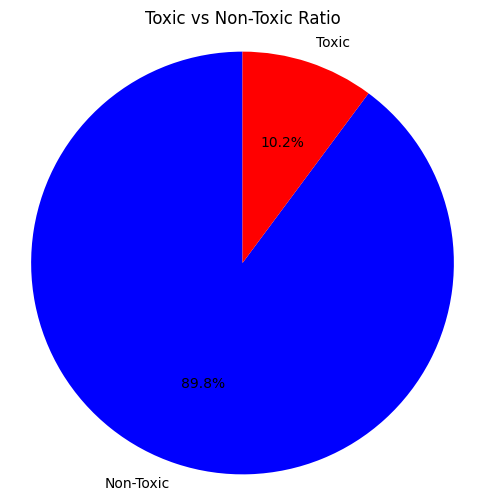

In [11]:
label_cols = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

toxic_count = (df[label_cols].sum(axis=1) > 0).sum()
non_toxic_count = (df[label_cols].sum(axis=1) == 0).sum()

sizes = [non_toxic_count, toxic_count]


labels = ['Non-Toxic', 'Toxic']

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['blue', 'red']
)
plt.title('Toxic vs Non-Toxic Ratio')
plt.axis('equal')
plt.show()


##  Handling Class Imbalance

The dataset is highly imbalanced, where **non-toxic comments dominate**.

To reduce model bias:
- We separate toxic and non-toxic comments
- Downsample non-toxic samples
- Create a balanced dataset


In [12]:
# Handle class imbalance (Downsampling Non-toxic)
label_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

toxic_df = df[df[label_cols].sum(axis=1) > 0]
non_toxic_df = df[df[label_cols].sum(axis=1) == 0]

non_toxic_df = non_toxic_df.sample(
    n=len(toxic_df),
    random_state=42
)

df = pd.concat([toxic_df, non_toxic_df]).sample(frac=1, random_state=42)

print("After balancing:", df.shape)


After balancing: (32450, 7)


In [13]:
df.head()

comment_text  \
57737                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [14]:
df.columns

Index(['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='object')

In [15]:
label=df.iloc[:,1:]
label

,toxic,severe_toxic,obscene,threat,insult,identity_hate
57737,1,0,0,0,1,0
46617,0,0,0,0,0,0
83356,1,0,0,0,0,0
34637,1,0,1,0,1,0
27887,1,1,1,0,1,1
...,...,...,...,...,...,...
19524,0,0,0,0,0,0
52404,1,0,0,0,0,0
8141,1,1,1,0,1,0
155400,1,0,1,0,1,1


In [16]:
nolabel=0
rowsums=df.iloc[:,1:].sum(axis=1)

for i, count in rowsums.items():
  if count==0:
    nolabel+=1
print('total comments', df.shape[0])
print('total comments with no label', nolabel)
print('total comments with label', df.shape[0]-nolabel)

total comments 32450
total comments with no label 16225
total comments with label 16225


##  Toxic vs Non-Toxic Distribution

This visualization shows the proportion of toxic and non-toxic comments
after applying class balancing.


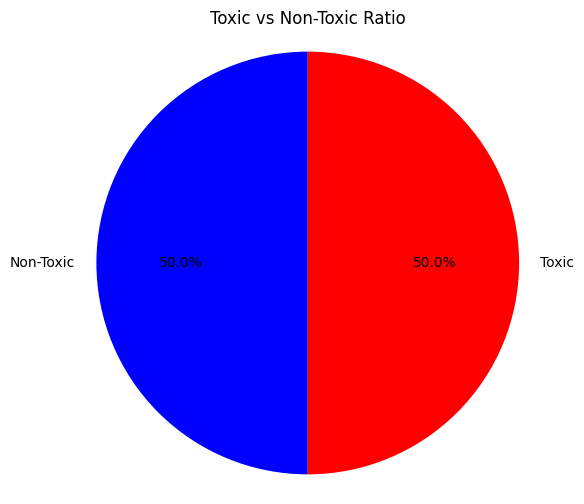

In [17]:
labels = ['Non-Toxic', 'Toxic']
sizes = [nolabel, df.shape[0] - nolabel]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['blue', 'red']
)
plt.title('Toxic vs Non-Toxic Ratio')
plt.axis('equal')
plt.show()

In [18]:
labels = ['Non-Toxic', 'Toxic']
sizes = [nolabel, df.shape[0] - nolabel]

fig = px.pie(
    names=labels,
    values=sizes,
    title='Toxic vs Non-Toxic Ratio',
    color=labels,
    color_discrete_map={
        'Non-Toxic': 'blue',
        'Toxic': 'red'
    }
)

fig.update_traces(
    textinfo='percent+label',
    textfont_size=14,
    pull=[0, 0]
)

fig.update_layout(
    width=500,
    height=500
)

fig.show()


In [19]:
label = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

label_counts = df[label].sum().sort_values(ascending=False)
label_percentages = (label_counts / len(df)) * 100

print("occurenc:")
print(label_counts)


occurenc:
toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [20]:
print("percentage:")
print(label_percentages.round(2),)

percentage:
toxic            47.13
obscene          26.04
insult           24.27
severe_toxic      4.92
identity_hate     4.33
threat            1.47
dtype: float64


##  Toxic Label Distribution

This section analyzes:
- Frequency of each toxicity label
- Percentage of comments containing each label


/tmp/ipython-input-1787413951.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




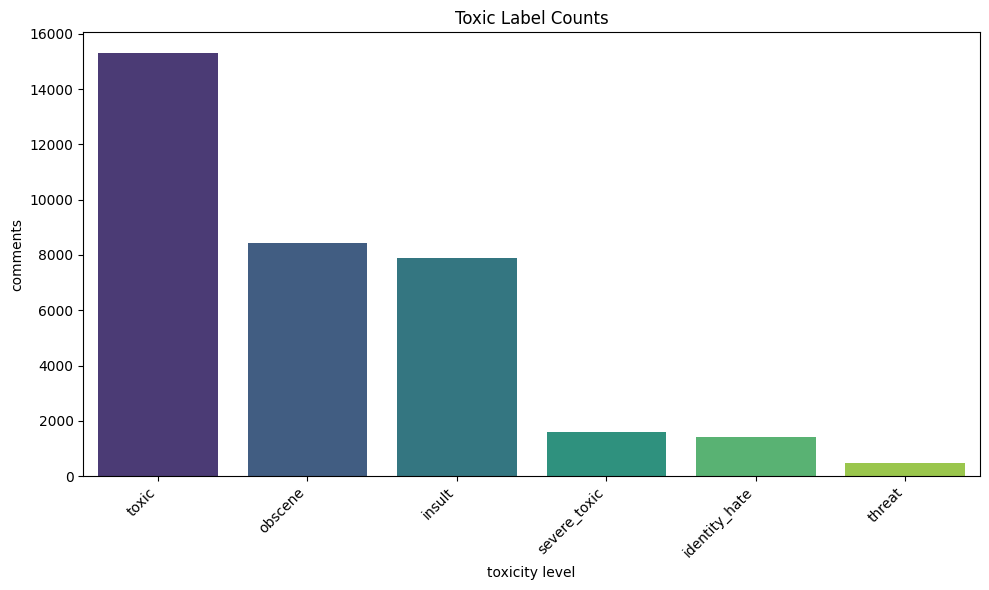

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title('Toxic Label Counts')
plt.ylabel('comments')
plt.xlabel('toxicity level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
fig = px.bar(
    x=label_counts.index,
    y=label_counts.values,
    labels={
        'x': 'toxicity level',
        'y': 'comments'
    },
    title='Toxic Label Counts',
    color=label_counts.values,
    color_continuous_scale='Viridis'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=800,
    height=500
)

fig.show()


##  Number of Labels per Comment

Since this is a multi-label problem,
each comment may contain more than one toxicity category.

We analyze how many labels appear per comment.


/tmp/ipython-input-2944709953.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




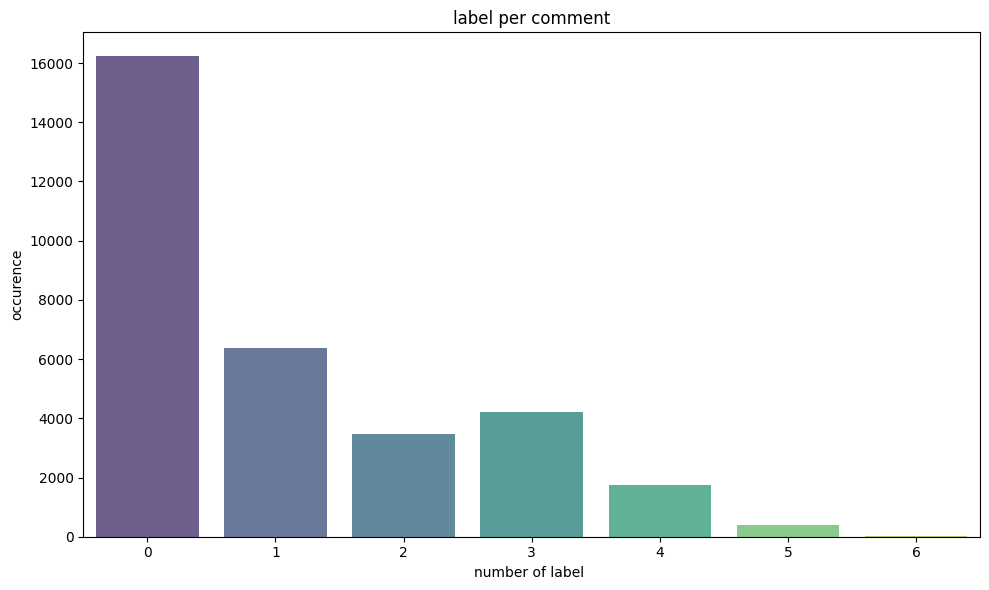

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(x=rowsums.values, alpha=0.8, palette="viridis")
plt.title('label per comment')
plt.ylabel('occurence')
plt.xlabel('number of label ')
plt.tight_layout()
plt.show()

In [24]:
fig = px.histogram(
    x=rowsums.values,
    nbins=len(set(rowsums.values)),
    labels={
        'x': 'number of label',
        'y': 'occurrence'
    },
    title='label per comment',
    color=rowsums.values,
    color_discrete_sequence=px.colors.sequential.Viridis
)

fig.update_layout(
    width=800,
    height=500,
    bargap=0.1
)

fig.show()


##  Multi-label Statistics

This section reports:
- Comments with zero labels
- Comments with one or more labels
- Comments with multiple overlapping toxicity types


In [25]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

label_sum = df[label_cols].sum(axis=1)

# Statistics
zero_labels = (label_sum == 0).sum()
one_or_more_labels = (label_sum >= 1).sum()
two_or_more_labels = (label_sum >= 2).sum()
three_or_more_labels = (label_sum >= 3).sum()
four_or_more_labels = (label_sum >= 4).sum()
five_or_more_labels = (label_sum >= 5).sum()
six_or_more_labels = (label_sum >= 6).sum()

print("Multi-label Statistics:")
print(f"Comments with 0 labels: {zero_labels}")
print(f"Comments with 1+ labels: {one_or_more_labels}")
print(f"Comments with 2+ labels: {two_or_more_labels}")
print(f"Comments with 3+ labels: {three_or_more_labels}")
print(f"Comments with 4+ labels: {four_or_more_labels}")
print(f"Comments with 5+ labels: {five_or_more_labels}")
print(f"Comments with 6+ labels: {six_or_more_labels}")


Multi-label Statistics:
Comments with 0 labels: 16225
Comments with 1+ labels: 16225
Comments with 2+ labels: 9865
Comments with 3+ labels: 6385
Comments with 4+ labels: 2176
Comments with 5+ labels: 416
Comments with 6+ labels: 31


##  Text Length Analysis

We examine:
- Character length distribution
- Word count distribution
- Outliers in text length


In [26]:
df['char_length'] = df['comment_text'].apply(len)

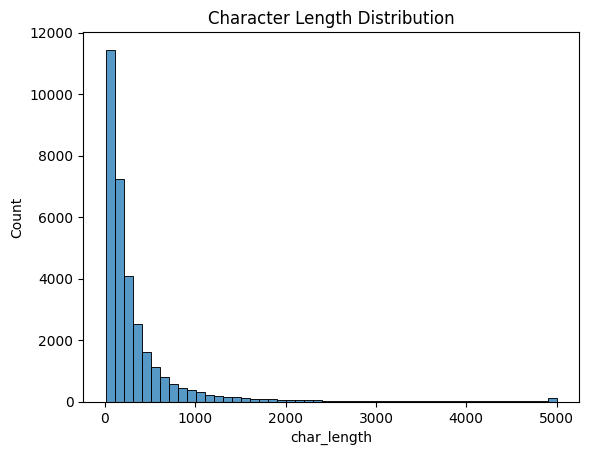

In [27]:
sns.histplot(df['char_length'], bins=50)
plt.title("Character Length Distribution")
plt.show()

In [28]:
fig = px.histogram(
    df,
    x='char_length',
    nbins=50,
    title='Character Length Distribution',
    labels={
        'char_length': 'Character Length',
        'count': 'Frequency'
    }
)

fig.update_layout(
    width=800,
    height=500
)

fig.show()


In [29]:
df['word_length'] = df['comment_text'].apply(lambda x: len(x.split()))

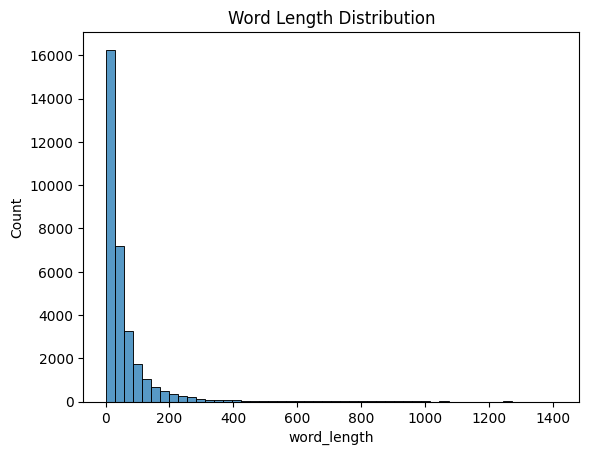

In [30]:
sns.histplot(df['word_length'], bins=50)
plt.title("Word Length Distribution")
plt.show()

In [31]:
fig = px.histogram(
    df,
    x='word_length',
    nbins=50,
    title="Word Length Distribution"
)

fig.update_layout(
    xaxis_title="Word Length",
    yaxis_title="Frequency",
    bargap=0.1
)

fig.show()


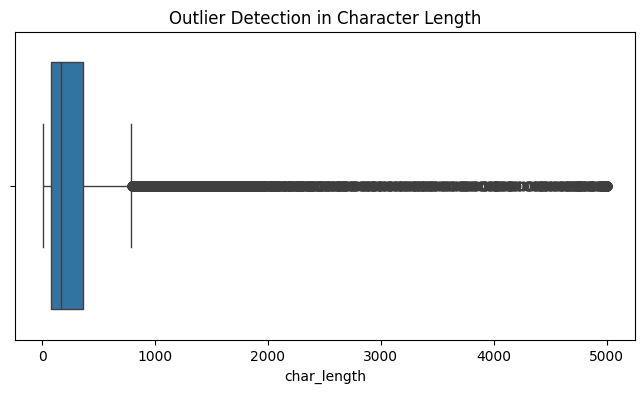

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['char_length'])
plt.title("Outlier Detection in Character Length")
plt.show()

In [33]:
fig = px.box(
    df,
    x='char_length',
    title="Outlier Detection in Character Length"
)

fig.update_layout(
    xaxis_title="Character Length",
    height=400
)

fig.show()


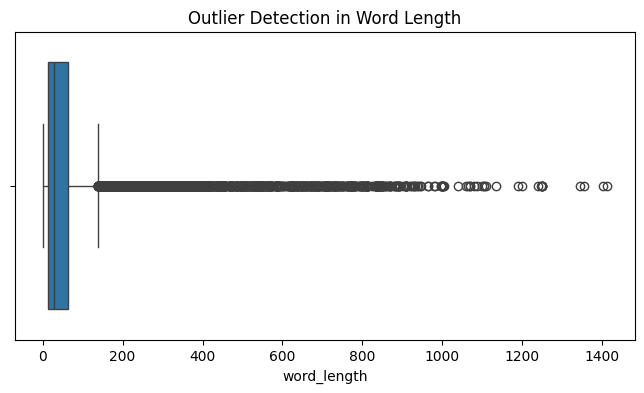

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['word_length'])
plt.title("Outlier Detection in Word Length")
plt.show()


In [35]:
fig = px.box(
    df,
    x='word_length',
    title="Outlier Detection in Word Length"
)

fig.update_layout(
    xaxis_title="Word Length",
    height=400
)

fig.show()


## Relationship Between Text Length and Toxicity

This visualization explores the relationship between:
- Comment length
- Number of toxic labels


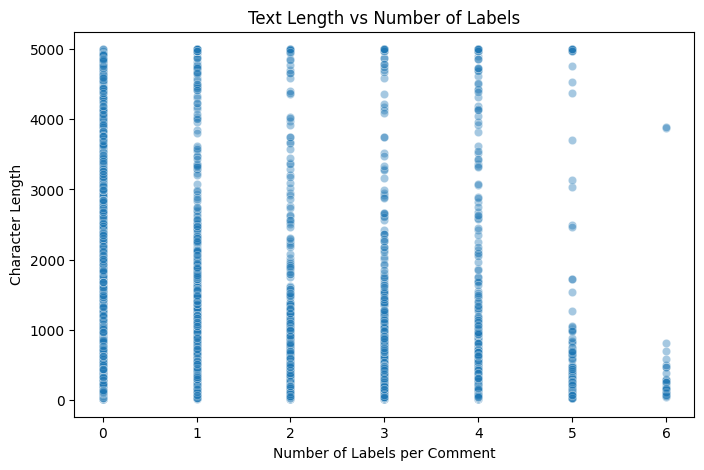

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=label_sum,
    y=df['char_length'],
    alpha=0.4
)
plt.xlabel("Number of Labels per Comment")
plt.ylabel("Character Length")
plt.title("Text Length vs Number of Labels")
plt.show()


In [37]:
fig = px.scatter(
    x=label_sum,
    y=df['char_length'],
    opacity=0.4,
    title="Text Length vs Number of Labels",
    labels={
        'x': 'Number of Labels per Comment',
        'y': 'Character Length'
    }
)

fig.update_layout(
    width=800,
    height=500
)

fig.show()


##  WordCloud Analysis

Word clouds highlight the most frequent words
associated with each toxicity category.


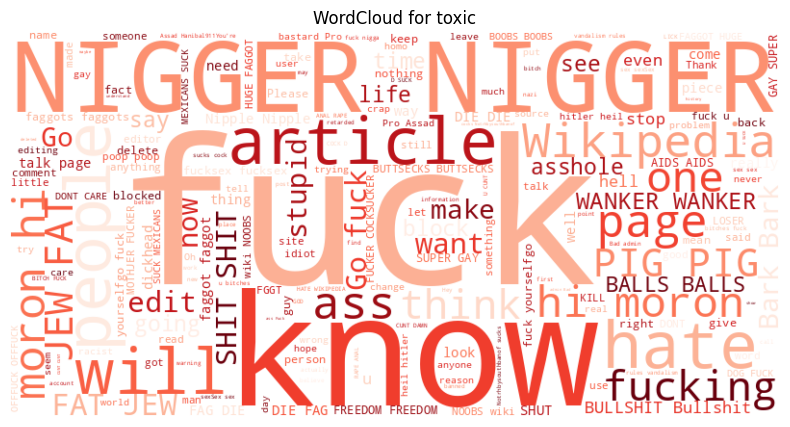

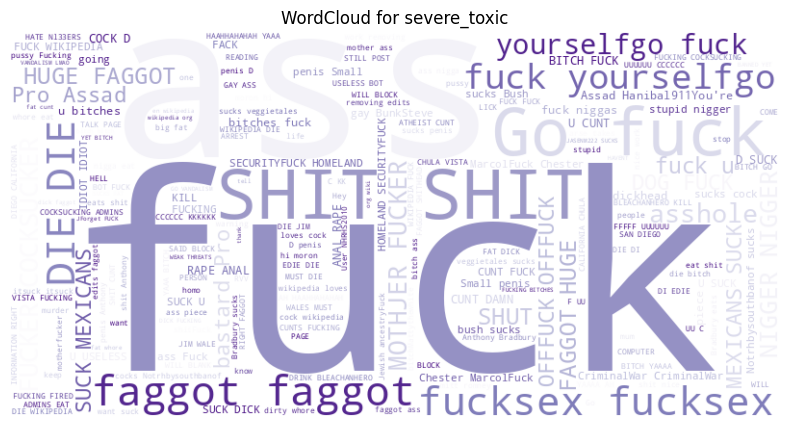

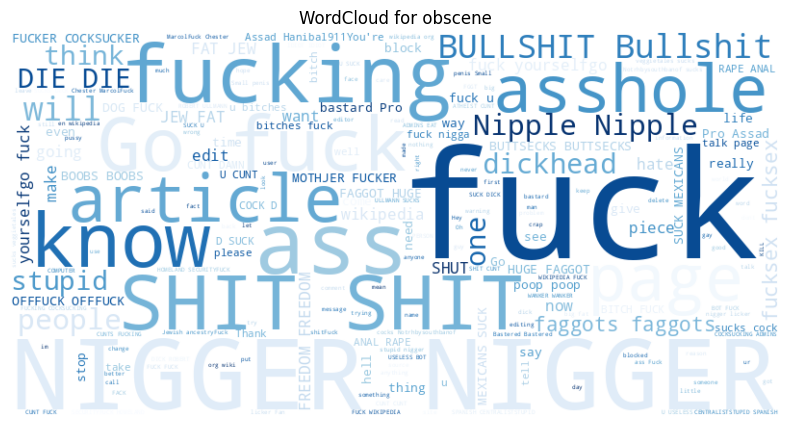

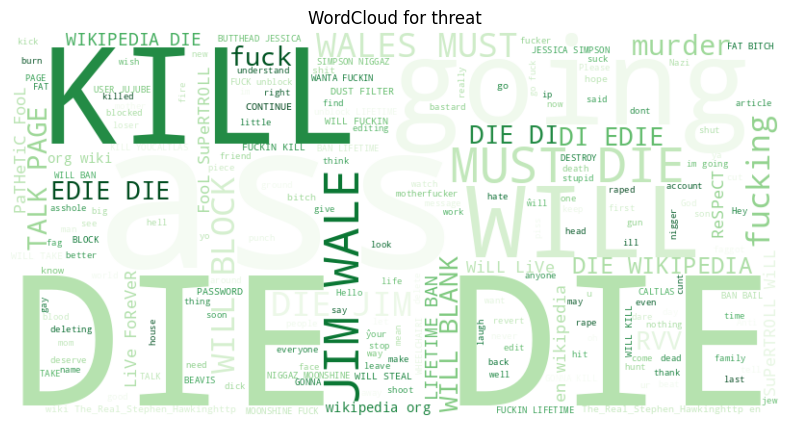

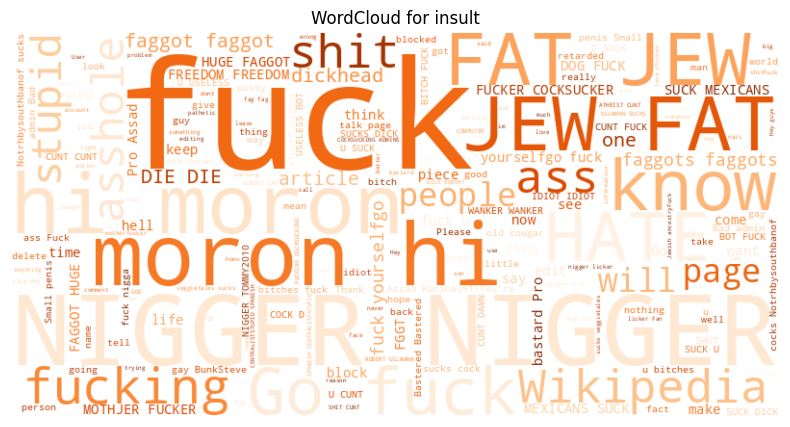

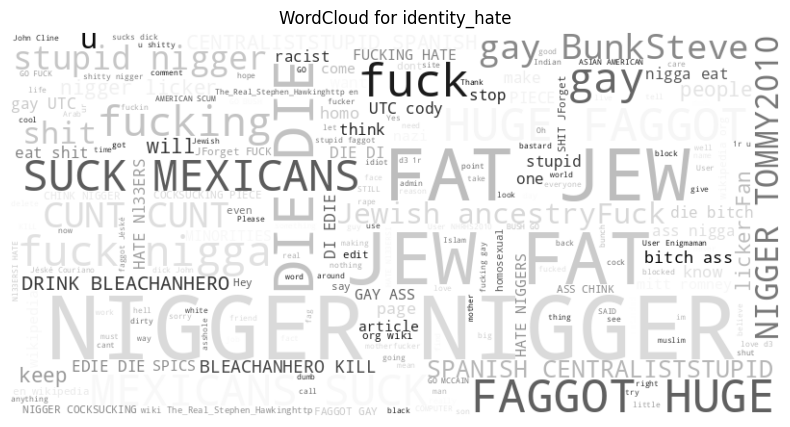

In [38]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


def plot_wordcloud(label, color):
    text = " ".join(df[df[label]==1]["comment_text"].astype(str))
    wc = WordCloud(width=800, height=400, background_color="white", colormap=color).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {label}")
    plt.show()

for label, color in zip(label_cols, ["Reds","Purples","Blues","Greens","Oranges","Greys"]):
    plot_wordcloud(label, color)

##  Label Correlation Analysis

This heatmap shows correlations between toxicity labels,
highlighting which toxic behaviors frequently co-occur.


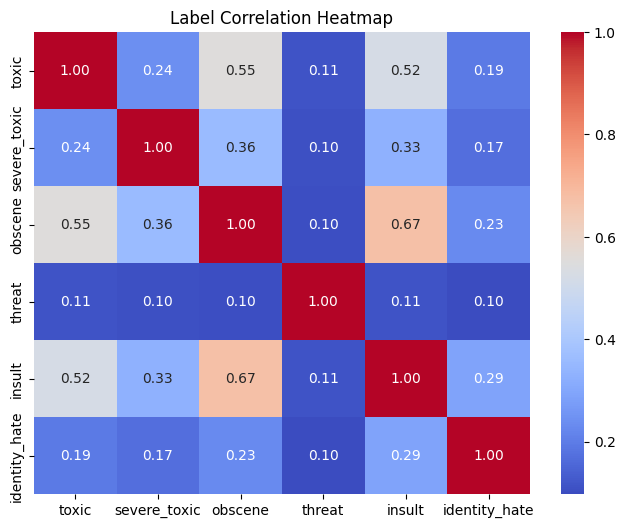

In [39]:
corr = df[label_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Label Correlation Heatmap")
plt.show()


In [40]:
corr = df[label_cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    title="Label Correlation Heatmap"
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()


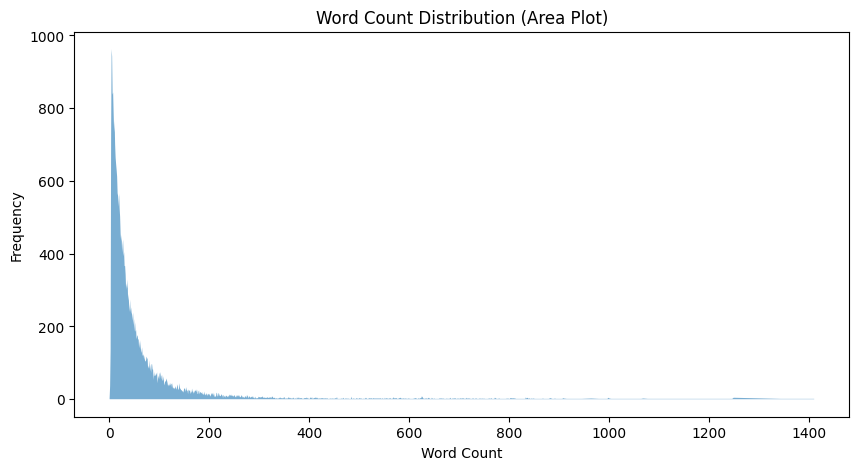

In [41]:
word_counts = df['word_length'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.fill_between(
    word_counts.index,
    word_counts.values,
    alpha=0.6
)
plt.title("Word Count Distribution (Area Plot)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


In [42]:
word_counts = df['word_length'].value_counts().sort_index()

fig = px.area(
    x=word_counts.index,
    y=word_counts.values,
    title="Word Count Distribution (Area Plot)",
    labels={
        'x': 'Word Count',
        'y': 'Frequency'
    }
)

fig.update_traces(opacity=0.6)

fig.update_layout(
    width=1000,
    height=500
)

fig.show()


##  Emoji Analysis

We analyze:
- Presence of emojis in comments
- Frequently used emojis
- Their association with toxic comments


In [43]:
def has_emoji(comment_text):
    return emoji.emoji_count(str(comment_text)) > 0

rows_with_emojis = df[df['comment_text'].progress_apply(has_emoji)]

print("\n number of rows with emojis:", len(rows_with_emojis))

100%|██████████| 32450/32450 [00:08<00:00, 3776.82it/s]


 number of rows with emojis: 172


In [44]:
all_emojis_list = []

def extract_emojis(comment_text):
    emojis = [item['emoji'] for item in emoji.emoji_list(str(comment_text))]
    return emojis
all_emojis_series = rows_with_emojis['comment_text'].progress_apply(extract_emojis)
all_emojis_list = all_emojis_series.explode().unique().tolist()

print(f"all unique emojies found: {len(all_emojis_list)}")
print("list of unique emojies:")
print(all_emojis_list)

100%|██████████| 172/172 [00:00<00:00, 3207.42it/s]

all unique emojies found: 34
list of unique emojies:
['✉', '♥', '♦', '♠', '♣', '™', '©', '®', '🍁', '✋🏼', '☎', '☺', '☘', '✌', '✍', '✔', '😄', '🍌', '✈', '↔', '☮', '❤', '😜', '☠', '☸', '😂', '☯', '😊', '☝', '👍', '💩', '🙈', '🙉', '🙊']


##  Text Preprocessing

To improve model performance, we apply a comprehensive preprocessing pipeline:
- Lowercasing
- Removing URLs, mentions, and hashtags
- Emoji to text conversion
- Stopword removal (while keeping negations)
- Contraction expansion
- Number normalization
- Lemmatization


In [45]:
stop_words = set(stopwords.words('english'))

stop_words_list = sorted(list(stop_words))

dfstopwords = pd.DataFrame(stop_words_list, columns=['Stop Word'])


In [46]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [47]:
# punctuation
all_punctuation = string.punctuation
punctuation_to_remove = all_punctuation.replace('?', '').replace('!', '').replace("'", '')

# stopwords
stop_words = set(stopwords.words('english'))

negation_words = {
    "not","no",
    "don't","isn't","wasn't","won't","aren't","didn't","hasn't",
    "couldn't","wouldn't","haven't","mustn't","needn't","shan't",
    "weren't","mightn't"
}

final_stop_words = stop_words - negation_words

# contractions
contractions_mapping = {
    "don't": "do not",
    "isn't": "is not",
    "wasn't": "was not",
    "won't": "will not",
    "aren't": "are not",
    "didn't": "did not",
    "hasn't": "has not",
    "couldn't": "could not",
    "wouldn't": "would not",
    "haven't": "have not",
    "mustn't": "must not",
    "needn't": "need not",
    "shan't": "shall not",
    "weren't": "were not",
    "mightn't": "might not",
    "i'm": "i am"
}

lemmatizer = WordNetLemmatizer()


In [48]:
def full_preprocess(comment_text):

    # lower
    comment_text = str(comment_text).lower()

    # remove punctuation except ?, !, '
    comment_text = ''.join(
        char for char in comment_text if char not in punctuation_to_remove
    )
    comment_text = re.sub(r'\s+', ' ', comment_text).strip()

    # remove URLs, mentions, hashtags
    comment_text = re.sub(r'http\S+|www\S+|https\S+', '', comment_text)
    comment_text = re.sub(r'@\w+', '', comment_text)
    comment_text = re.sub(r'#', '', comment_text)
    comment_text = re.sub(r'\s+', ' ', comment_text).strip()

    # emoji to text
    comment_text = emoji.demojize(comment_text, delimiters=(" ", " "))
    comment_text = re.sub(r'\s+', ' ', comment_text).strip()

    # remove stopwords (keep negations)
    words = comment_text.split()
    words = [w for w in words if w not in final_stop_words]
    comment_text = " ".join(words)

    # expand contractions
    contractions_pattern = re.compile(
        '({})'.format('|'.join(re.escape(k) for k in contractions_mapping.keys())),
        flags=re.IGNORECASE
    )

    def replace_match(match):
        return contractions_mapping[match.group(0).lower()]

    comment_text = contractions_pattern.sub(replace_match, comment_text)

    # numbers to words then remove digits
    def replacer(match):
        try:
            return num2words(int(match.group(0)), lang='en')
        except:
            return match.group(0)

    comment_text = re.sub(r'\b\d+\b', replacer, comment_text)
    comment_text = re.sub(r'[0-9]', '', comment_text)

    # clean spaces
    comment_text = re.sub(r'\s+', ' ', comment_text).strip()

    # lemmatization
    words = comment_text.split()
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)


In [49]:
df['comment_text'] = df['comment_text'].progress_apply(full_preprocess)


100%|██████████| 32450/32450 [00:23<00:00, 1357.85it/s]


##  Feature Engineering

In addition to text features, we extract numerical features:
- Word count
- Character length
- Punctuation count
- Unique word ratio

These features are combined with TF-IDF representations.


In [50]:
def add_text_features(df, text_col='comment_text'):

    # Word count
    df['word_count_afterprprocess'] = df[text_col].apply(lambda x: len(x.split()))

    # Character length
    df['char_length'] = df[text_col].apply(len)

    # Punctuation count
    df['punctuation_count'] = df[text_col].apply(
        lambda x: sum(1 for c in x if c in string.punctuation)
    )

    # Unique word ratio
    df['unique_word_ratio'] = df[text_col].apply(
        lambda x: len(set(x.split())) / max(len(x.split()), 1)
    )

    return df


In [51]:
df = add_text_features(df)
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,char_length,word_length,word_count_afterprprocess,punctuation_count,unique_word_ratio
57737,old cougar! old cougar!,1,0,0,0,1,0,23,10,4,2,0.500000
46617,scared brrrr gonna die,0,0,0,0,0,0,22,7,4,0,1.000000
83356,"okay anal sex widely unaccepted disgusting evil animal abuse animal murder? do not understand put anal sex category thing may not like pedophilia rape smack strong homophobic stance username questionably based homophobic slur come conclusion two plus two equal four two hundred and forty-two million, eight hundred and seventy thousand, one hundred and twenty-nine",1,0,0,0,0,0,364,73,54,5,0.796296
34637,shut cunt,1,0,1,0,1,0,9,5,2,0,1.000000
27887,arrogant administrator homosexual bastard fuck,1,1,1,0,1,1,46,7,5,0,1.000000


In [52]:
scaler = StandardScaler()
num_features = scaler.fit_transform(
    df[['word_count_afterprprocess', 'char_length', 'punctuation_count', 'unique_word_ratio']]
)


In [53]:
bow = CountVectorizer(max_features=10000, ngram_range=(1,2))
X_bow = bow.fit_transform(df['comment_text'])


In [54]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_text = tfidf.fit_transform(df['comment_text'])
X = hstack([X_text, num_features])

label_cols = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

y = df[label_cols]

##  Data Splitting

The dataset is split into:
- 80% Training
- 10% Validation
- 10% Testing

This ensures fair evaluation and prevents data leakage.


In [55]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (25960, 10004)
Validation: (3245, 10004)
Test: (3245, 10004)


In [56]:
def show_distribution(y, name):
    print(f"\n{name}")
    print(y.value_counts(normalize=True) * 100)

show_distribution(y_train, "Train")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")



Train
toxic  severe_toxic  obscene  threat  insult  identity_hate
0      0             0        0       0       0                49.922958
1      0             0        0       0       0                17.488444
                     1        0       1       0                11.667951
                                      0       0                 5.473806
                     0        0       1       0                 3.686441
       1             1        0       1       0                 3.066256
       0             1        0       1       1                 2.003082
0      0             1        0       0       0                 0.978428
                     0        0       1       0                 0.959168
1      1             1        0       1       1                 0.770416
0      0             1        0       1       0                 0.523883
1      1             1        0       0       0                 0.489214
       0             0        0       0       1          

##  Classical Machine Learning Models

We experiment with:
- Logistic Regression (One-vs-Rest)
- Support Vector Machine (LinearSVC)

Both models use:
- TF-IDF features
- Balanced class weights


In [57]:
lr = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    )
)

lr.fit(X_train, y_train)


OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000))

In [58]:
svm = OneVsRestClassifier(
    LinearSVC(class_weight='balanced')
)

svm.fit(X_train, y_train)


OneVsRestClassifier(estimator=LinearSVC(class_weight='balanced'))

In [59]:
y_prob_lr = lr.predict_proba(X_test)
threshold = 0.3
y_pred_lr = (y_prob_lr >= threshold).astype(int)


In [60]:
y_score_svm = svm.decision_function(X_test)
y_pred_svm = (y_score_svm >= 0).astype(int)


In [61]:
def evaluate_multilabel(
    y_true,
    y_pred,
    y_prob,
    model_name,
    label_cols
):
    print(f"\n================ {model_name} ================")


    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_cols,
            zero_division=0
        )
    )


    acc = accuracy_score(y_true, y_pred)


    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro    = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro        = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro        = f1_score(y_true, y_pred, average='macro', zero_division=0)


    roc_auc = roc_auc_score(y_true, y_prob, average='macro')

    print("Overall Metrics:")
    print(f"Accuracy (Subset): {acc:.4f}")
    print(f"Precision (Micro): {precision_micro:.4f}")
    print(f"Recall (Micro):    {recall_micro:.4f}")
    print(f"F1-score (Micro):  {f1_micro:.4f}")
    print("-" * 40)
    print(f"Precision (Macro): {precision_macro:.4f}")
    print(f"Recall (Macro):    {recall_macro:.4f}")
    print(f"F1-score (Macro):  {f1_macro:.4f}")
    print("-" * 40)
    print(f"ROC-AUC (Macro):   {roc_auc:.4f}")


In [62]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)


In [63]:
evaluate_multilabel(
    y_test,
    y_pred_lr,
    y_prob_lr,
    "Logistic Regression",
    label_cols
)



================ Logistic Regression ================
               precision    recall  f1-score   support

        toxic       0.87      0.85      0.86      1530
 severe_toxic       0.36      0.79      0.49       173
      obscene       0.81      0.83      0.82       839
       threat       0.28      0.66      0.39        44
       insult       0.65      0.76      0.70       767
identity_hate       0.32      0.80      0.46       124

    micro avg       0.70      0.82      0.76      3477
    macro avg       0.55      0.78      0.62      3477
 weighted avg       0.75      0.82      0.78      3477
  samples avg       0.32      0.38      0.34      3477

Overall Metrics:
Accuracy (Subset): 0.6037
Precision (Micro): 0.7025
Recall (Micro):    0.8162
F1-score (Micro):  0.7551
----------------------------------------
Precision (Macro): 0.5479
Recall (Macro):    0.7799
F1-score (Macro):  0.6202
----------------------------------------
ROC-AUC (Macro):   0.9455


In [64]:

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.decision_function(X_test)


In [65]:
evaluate_multilabel(
    y_test,
    y_pred_svm,
    y_prob_svm,
    "SVM",
    label_cols
)



================ SVM ================
               precision    recall  f1-score   support

        toxic       0.86      0.86      0.86      1530
 severe_toxic       0.38      0.62      0.47       173
      obscene       0.79      0.81      0.80       839
       threat       0.38      0.57      0.46        44
       insult       0.62      0.72      0.66       767
identity_hate       0.32      0.61      0.42       124

    micro avg       0.71      0.79      0.75      3477
    macro avg       0.56      0.70      0.61      3477
 weighted avg       0.74      0.79      0.76      3477
  samples avg       0.34      0.38      0.34      3477

Overall Metrics:
Accuracy (Subset): 0.5994
Precision (Micro): 0.7148
Recall (Micro):    0.7935
F1-score (Micro):  0.7521
----------------------------------------
Precision (Macro): 0.5603
Recall (Macro):    0.6993
F1-score (Macro):  0.6137
----------------------------------------
ROC-AUC (Macro):   0.9285


##  Deep Learning Models

To capture sequential patterns in text, we implement:
- CNN
- LSTM
- GRU

All models:
- Use embedding layers
- Apply sigmoid activation for multi-label output
- Optimize binary cross-entropy loss


In [66]:
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['comment_text'])

sequences = tokenizer.texts_to_sequences(df['comment_text'])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

y_seq = df[label_cols].values

print(X_seq.shape, y_seq.shape)


(32450, 200) (32450, 6)


In [67]:
X_train_nn, X_temp_nn, y_train_nn, y_temp_nn = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

X_val_nn, X_test_nn, y_val_nn, y_test_nn = train_test_split(
    X_temp_nn,
    y_temp_nn,
    test_size=0.5,
    random_state=42
)

print("Train:", X_train_nn.shape)
print("Validation:", X_val_nn.shape)
print("Test:", X_test_nn.shape)


Train: (25960, 200)
Validation: (3245, 200)
Test: (3245, 200)


In [68]:
class_weights = {}

for i, label in enumerate(label_cols):
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0,1]),
        y=y_train_nn[:, i]
    )
    class_weights[i] = {0: weights[0], 1: weights[1]}

class_weights


{0: {0: np.float64(0.9466851433155861), 1: np.float64(1.0596783410890684)},
 1: {0: np.float64(0.5256550439395781), 1: np.float64(10.244672454617206)},
 2: {0: np.float64(0.6765702371644514), 1: np.float64(1.9158671586715867)},
 3: {0: np.float64(0.5074276778733385), 1: np.float64(34.1578947368421)},
 4: {0: np.float64(0.6601230737934191), 1: np.float64(2.061299031284739)},
 5: {0: np.float64(0.5231339674351121), 1: np.float64(11.306620209059233)}}

In [69]:


cnn = Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),
    Embedding(MAX_WORDS, 128),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='sigmoid')
])



cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True)]
)

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,650,694 (10.11 MB)

 Trainable params: 2,650,694 (10.11 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
history= cnn.fit(
    X_train_nn,
    y_train_nn,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_nn, y_val_nn),

)


Epoch 1/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - auc: 0.6563 - loss: 0.3820 - val_auc: 0.9035 - val_loss: 0.1998
Epoch 2/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.8886 - loss: 0.1980 - val_auc: 0.9181 - val_loss: 0.1850
Epoch 3/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc: 0.9146 - loss: 0.1680 - val_auc: 0.9246 - val_loss: 0.1872
Epoch 4/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.9440 - loss: 0.1436 - val_auc: 0.9206 - val_loss: 0.1990
Epoch 5/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.9618 - loss: 0.1254 - val_auc: 0.9089 - val_loss: 0.2225


##  Threshold Tuning

Instead of using a fixed threshold (0.5),
we tune **a separate threshold for each label**
to maximize the F1-score.

This significantly improves detection of rare toxic categories.


In [71]:
def find_best_thresholds(y_true, y_prob):
    thresholds = []
    for i in range(y_true.shape[1]):
        best_f1 = 0
        best_t = 0.5
        for t in np.arange(0.1, 0.9, 0.05):
            y_pred = (y_prob[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        thresholds.append(best_t)
    return thresholds



y_prob_cnn = cnn.predict(X_test_nn)


thresholds_cnn = find_best_thresholds(y_test_nn, y_prob_cnn)


y_pred_cnn = np.zeros_like(y_prob_cnn)
for i, t in enumerate(thresholds_cnn):
    y_pred_cnn[:, i] = (y_prob_cnn[:, i] >= t).astype(int)


evaluate_multilabel(
    y_test_nn,
    y_pred_cnn,
    y_prob_cnn,
    "CNN (Threshold Tuned)",
    label_cols
)

print("Best thresholds per label:")
for label, t in zip(label_cols, thresholds_cnn):
    print(f"{label}: {t:.2f}")


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

================ CNN (Threshold Tuned) ================
               precision    recall  f1-score   support

        toxic       0.87      0.88      0.87      1530
 severe_toxic       0.46      0.58      0.51       173
      obscene       0.79      0.84      0.81       839
       threat       0.15      0.16      0.16        44
       insult       0.61      0.83      0.70       767
identity_hate       0.31      0.61      0.41       124

    micro avg       0.72      0.82      0.77      3477
    macro avg       0.53      0.65      0.58      3477
 weighted avg       0.74      0.82      0.78      3477
  samples avg       0.34      0.39      0.35      3477

Overall Metrics:
Accuracy (Subset): 0.6299
Precision (Micro): 0.7170
Recall (Micro):    0.8240
F1-score (Micro):  0.7668
----------------------------------------
Precision (Macro): 0.5314
Recall (Macro):    0.6493
F1-score (Macro):  0.5780
----------------------------------------
ROC-AUC (Macr

In [72]:
lstm = Sequential([
    Embedding(MAX_WORDS, 128, input_shape=(MAX_LEN,)),
    LSTM(64),
    Dense(6, activation='sigmoid')
])


lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True)]
)

lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,798 (9.96 MB)

 Trainable params: 2,609,798 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
history2=lstm.fit(
    X_train_nn,
    y_train_nn,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_nn, y_val_nn)

)


Epoch 1/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc_1: 0.4957 - loss: 0.4030 - val_auc_1: 0.5081 - val_loss: 0.3781
Epoch 2/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - auc_1: 0.5006 - loss: 0.3796 - val_auc_1: 0.5115 - val_loss: 0.3763
Epoch 3/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc_1: 0.5071 - loss: 0.3723 - val_auc_1: 0.5127 - val_loss: 0.3759
Epoch 4/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - auc_1: 0.5277 - loss: 0.3713 - val_auc_1: 0.8661 - val_loss: 0.2848
Epoch 5/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - auc_1: 0.8628 - loss: 0.2389 - val_auc_1: 0.8969 - val_loss: 0.1959


In [74]:
def find_best_thresholds(y_true, y_prob):
    thresholds = []
    for i in range(y_true.shape[1]):
        best_f1 = 0
        best_t = 0.5
        for t in np.arange(0.1, 0.9, 0.05):
            y_pred = (y_prob[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        thresholds.append(best_t)
    return thresholds



y_prob_lstm = lstm.predict(X_test_nn)


thresholds_lstm = find_best_thresholds(y_test_nn, y_prob_lstm)


y_pred_lstm = np.zeros_like(y_prob_lstm)
for i, t in enumerate(thresholds_lstm):
    y_pred_lstm[:, i] = (y_prob_lstm[:, i] >= t).astype(int)


evaluate_multilabel(
    y_test_nn,
    y_pred_lstm,
    y_prob_lstm,
    "lstm (Threshold Tuned)",
    label_cols
)

print("Best thresholds per label:")
for label, t in zip(label_cols, thresholds_lstm):
    print(f"{label}: {t:.2f}")


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

================ lstm (Threshold Tuned) ================
               precision    recall  f1-score   support

        toxic       0.86      0.90      0.88      1530
 severe_toxic       0.38      0.72      0.50       173
      obscene       0.74      0.89      0.81       839
       threat       0.00      0.00      0.00        44
       insult       0.65      0.80      0.72       767
identity_hate       0.20      0.39      0.26       124

    micro avg       0.70      0.84      0.76      3477
    macro avg       0.47      0.62      0.53      3477
 weighted avg       0.72      0.84      0.77      3477
  samples avg       0.35      0.40      0.35      3477

Overall Metrics:
Accuracy (Subset): 0.6173
Precision (Micro): 0.7009
Recall (Micro):    0.8369
F1-score (Micro):  0.7629
----------------------------------------
Precision (Macro): 0.4685
Recall (Macro):    0.6171
F1-score (Macro):  0.5258
----------------------------------------
ROC-AUC (Mac

In [75]:
gru = Sequential([
    Embedding(MAX_WORDS, 128, input_shape=(MAX_LEN,)),
    GRU(64),
    Dense(6, activation='sigmoid')
])


gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True)]
)

gru.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597,638 (9.91 MB)

 Trainable params: 2,597,638 (9.91 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
history3=gru.fit(
    X_train_nn,
    y_train_nn,
    epochs=5,
    batch_size=64,
    validation_data=(X_val_nn, y_val_nn)

)


Epoch 1/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - auc_2: 0.5014 - loss: 0.4105 - val_auc_2: 0.7485 - val_loss: 0.2872
Epoch 2/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - auc_2: 0.8551 - loss: 0.2154 - val_auc_2: 0.9063 - val_loss: 0.1852
Epoch 3/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - auc_2: 0.9165 - loss: 0.1648 - val_auc_2: 0.9213 - val_loss: 0.1788
Epoch 4/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc_2: 0.9449 - loss: 0.1382 - val_auc_2: 0.9251 - val_loss: 0.1850
Epoch 5/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - auc_2: 0.9621 - loss: 0.1202 - val_auc_2: 0.9259 - val_loss: 0.1945


In [77]:
def find_best_thresholds(y_true, y_prob):
    thresholds = []
    for i in range(y_true.shape[1]):
        best_f1 = 0
        best_t = 0.5
        for t in np.arange(0.1, 0.9, 0.05):
            y_pred = (y_prob[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        thresholds.append(best_t)
    return thresholds



y_prob_gru = gru.predict(X_test_nn)


thresholds_gru = find_best_thresholds(y_test_nn, y_prob_gru)


y_pred_gru = np.zeros_like(y_prob_gru)
for i, t in enumerate(thresholds_gru):
    y_pred_gru[:, i] = (y_prob_gru[:, i] >= t).astype(int)


evaluate_multilabel(
    y_test_nn,
    y_pred_gru,
    y_prob_gru,
    "gru (Threshold Tuned)",
    label_cols
)

print("Best thresholds per label:")
for label, t in zip(label_cols, thresholds_gru):
    print(f"{label}: {t:.2f}")


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

================ gru (Threshold Tuned) ================
               precision    recall  f1-score   support

        toxic       0.84      0.90      0.87      1530
 severe_toxic       0.40      0.75      0.52       173
      obscene       0.81      0.86      0.84       839
       threat       0.15      0.48      0.23        44
       insult       0.68      0.76      0.72       767
identity_hate       0.46      0.55      0.50       124

    micro avg       0.72      0.83      0.78      3477
    macro avg       0.56      0.72      0.61      3477
 weighted avg       0.75      0.83      0.79      3477
  samples avg       0.36      0.40      0.36      3477

Overall Metrics:
Accuracy (Subset): 0.6296
Precision (Micro): 0.7247
Recall (Micro):    0.8349
F1-score (Micro):  0.7759
----------------------------------------
Precision (Macro): 0.5567
Recall (Macro):    0.7166
F1-score (Macro):  0.6121
----------------------------------------
ROC-AUC (Macr

In [78]:
lr_base = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

lr_ovr = OneVsRestClassifier(lr_base)

param_grid_lr = {
    'estimator__C': [0.01, 0.1, 1, 10],
    'estimator__penalty': ['l1', 'l2']
}


In [79]:
grid_lr = GridSearchCV(
    estimator=lr_ovr,
    param_grid=param_grid_lr,
    scoring='f1_micro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_lr.fit(X_train, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                                        max_iter=2000,
                                                                        solver='liblinear')),
             n_jobs=-1,
             param_grid={'estimator__C': [0.01, 0.1, 1, 10],
                         'estimator__penalty': ['l1', 'l2']},
             scoring='f1_micro', verbose=2)

In [80]:
print("Best Logistic Regression Params:")
print(grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)

evaluate_multilabel(
    y_test,
    y_pred_lr,
    y_prob_lr,
    "Tuned Logistic Regression",
    label_cols
)


Best Logistic Regression Params:
{'estimator__C': 1, 'estimator__penalty': 'l1'}

================ Tuned Logistic Regression ================
               precision    recall  f1-score   support

        toxic       0.89      0.82      0.86      1530
 severe_toxic       0.34      0.76      0.47       173
      obscene       0.83      0.84      0.84       839
       threat       0.26      0.68      0.38        44
       insult       0.65      0.78      0.71       767
identity_hate       0.33      0.79      0.46       124

    micro avg       0.71      0.81      0.76      3477
    macro avg       0.55      0.78      0.62      3477
 weighted avg       0.77      0.81      0.78      3477
  samples avg       0.32      0.38      0.33      3477

Overall Metrics:
Accuracy (Subset): 0.6083
Precision (Micro): 0.7107
Recall (Micro):    0.8110
F1-score (Micro):  0.7576
----------------------------------------
Precision (Macro): 0.5514
Recall (Macro):    0.7793
F1-score (Macro):  0.6190
----------

In [81]:
svm_base = LinearSVC(
    class_weight='balanced'
)

svm_ovr = OneVsRestClassifier(svm_base)

param_grid_svm = {
    'estimator__C': [0.01, 0.1, 1, 10]
}


In [82]:
grid_svm = GridSearchCV(
    estimator=svm_ovr,
    param_grid=param_grid_svm,
    scoring='f1_micro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=OneVsRestClassifier(estimator=LinearSVC(class_weight='balanced')),
             n_jobs=-1, param_grid={'estimator__C': [0.01, 0.1, 1, 10]},
             scoring='f1_micro', verbose=2)

In [83]:
print("Best SVM Params:")
print(grid_svm.best_params_)

best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_score_svm = best_svm.decision_function(X_test)

evaluate_multilabel(
    y_test,
    y_pred_svm,
    y_score_svm,
    "Tuned SVM",
    label_cols
)


Best SVM Params:
{'estimator__C': 0.1}

================ Tuned SVM ================
               precision    recall  f1-score   support

        toxic       0.88      0.85      0.86      1530
 severe_toxic       0.35      0.79      0.48       173
      obscene       0.81      0.83      0.82       839
       threat       0.28      0.66      0.39        44
       insult       0.65      0.77      0.70       767
identity_hate       0.32      0.81      0.45       124

    micro avg       0.70      0.82      0.76      3477
    macro avg       0.55      0.78      0.62      3477
 weighted avg       0.76      0.82      0.78      3477
  samples avg       0.32      0.38      0.33      3477

Overall Metrics:
Accuracy (Subset): 0.6028
Precision (Micro): 0.7016
Recall (Micro):    0.8182
F1-score (Micro):  0.7554
----------------------------------------
Precision (Macro): 0.5472
Recall (Macro):    0.7835
F1-score (Macro):  0.6196
----------------------------------------
ROC-AUC (Macro):   0.9452


In [84]:

def build_cnn(
    embedding_dim=128,
    filters=128,
    kernel_size=5,
    dropout_rate=0.5
):
    model = Sequential([
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=embedding_dim,
            input_shape=(MAX_LEN,)
        ),
        Conv1D(filters, kernel_size, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(6, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(multi_label=True)]
    )

    return model


In [85]:
cnn_configs = [
    {'embedding_dim': 128, 'filters': 128, 'kernel_size': 5, 'dropout_rate': 0.5},
    {'embedding_dim': 128, 'filters': 256, 'kernel_size': 5, 'dropout_rate': 0.5},
    {'embedding_dim': 100, 'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.3}
]


In [86]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

for i, cfg in enumerate(cnn_configs):
    print(f"\nTraining CNN config {i+1}: {cfg}")

    cnn = build_cnn(**cfg)

    cnn.fit(
        X_train_nn,
        y_train_nn,
        epochs=10,
        batch_size=64,
        validation_data=(X_val_nn, y_val_nn),
        callbacks=[early_stop],
        verbose=1,

    )

    y_prob_cnn = cnn.predict(X_test_nn)
    y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

    evaluate_multilabel(
        y_test_nn,
        y_pred_cnn,
        y_prob_cnn,
        f"CNN Tuned Config {i+1}",
        label_cols
    )



Training CNN config 1: {'embedding_dim': 128, 'filters': 128, 'kernel_size': 5, 'dropout_rate': 0.5}
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



406/406 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - auc_3: 0.6419 - loss: 0.3981 - val_auc_3: 0.9089 - val_loss: 0.1904
Epoch 2/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_3: 0.8878 - loss: 0.1929 - val_auc_3: 0.9221 - val_loss: 0.1859
Epoch 3/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc_3: 0.9311 - loss: 0.1642 - val_auc_3: 0.9258 - val_loss: 0.1852
Epoch 4/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc_3: 0.9579 - loss: 0.1381 - val_auc_3: 0.9215 - val_loss: 0.1917
Epoch 5/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc_3: 0.9693 - loss: 0.1163 - val_auc_3: 0.9171 - val_loss: 0.2084
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

================ CNN Tuned Config 1 ================
               precision    recall  f1-score   support

        toxic       0.87      0.87      0.87      1530
 severe_toxic       0.53      0.22      0.31       173
      obscene       0.86      0.77      0.81       839
       threat       0.00      0.00      0.00        44
       insult       0.73     

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



406/406 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - auc_4: 0.6737 - loss: 0.3582 - val_auc_4: 0.9077 - val_loss: 0.1893
Epoch 2/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_4: 0.8934 - loss: 0.1872 - val_auc_4: 0.9248 - val_loss: 0.1796
Epoch 3/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - auc_4: 0.9385 - loss: 0.1545 - val_auc_4: 0.9257 - val_loss: 0.1848
Epoch 4/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_4: 0.9602 - loss: 0.1303 - val_auc_4: 0.9132 - val_loss: 0.2052
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

================ CNN Tuned Config 2 ================
               precision    recall  f1-score   support

        toxic       0.86      0.88      0.87      1530
 severe_toxic       0.58      0.13      0.21       173
      obscene       0.83      0.82      0.83       839
       threat       0.00      0.00      0.00        44
       insult       0.72      0.66      0.69       767
identity_hate       0.00      0.00      0.00       124

    micro avg       0.82      0.74     

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



406/406 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - auc_5: 0.6656 - loss: 0.3831 - val_auc_5: 0.9002 - val_loss: 0.1915
Epoch 2/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc_5: 0.8926 - loss: 0.1863 - val_auc_5: 0.9116 - val_loss: 0.1869
Epoch 3/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc_5: 0.9302 - loss: 0.1609 - val_auc_5: 0.9278 - val_loss: 0.1818
Epoch 4/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc_5: 0.9580 - loss: 0.1340 - val_auc_5: 0.9272 - val_loss: 0.1894
Epoch 5/10
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc_5: 0.9718 - loss: 0.1099 - val_auc_5: 0.9200 - val_loss: 0.2038
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

================ CNN Tuned Config 3 ================
               precision    recall  f1-score   support

        toxic       0.83      0.91      0.87      1530
 severe_toxic       0.56      0.14      0.22       173
      obscene       0.86      0.81      0.84       839
       threat       0.00      0.00      0.00        44
       insult       0.71    

##  Model Performance Comparison

Models are compared using:
- Accuracy (subset accuracy)
- Precision, Recall, F1-score
- ROC-AUC (macro)

Results are visualized for easy comparison.


In [87]:
results = []

def collect_results(model_name, y_true, y_pred, y_prob):
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Micro)": precision_score(y_true, y_pred, average='micro', zero_division=0),
        "Recall (Micro)": recall_score(y_true, y_pred, average='micro', zero_division=0),
        "F1-score (Micro)": f1_score(y_true, y_pred, average='micro', zero_division=0),
        "ROC-AUC (Macro)": roc_auc_score(y_true, y_prob, average='macro')
    })

# ML
collect_results("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
collect_results("SVM", y_test, y_pred_svm, y_score_svm)

# Deep Learning
collect_results("CNN", y_test_nn, y_pred_cnn, y_prob_cnn)
collect_results("LSTM", y_test_nn, y_pred_lstm, y_prob_lstm)
collect_results("GRU", y_test_nn, y_pred_gru, y_prob_gru)

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision (Micro),Recall (Micro),F1-score (Micro),ROC-AUC (Macro)
0,Logistic Regression,0.608320,0.710685,0.811044,0.757555,0.945566
1,SVM,0.602773,0.701603,0.818234,0.755443,0.945245
2,CNN,0.653005,0.805938,0.757262,0.780842,0.927646
3,LSTM,0.617257,0.700867,0.836928,0.762878,0.900269
4,GRU,0.629584,0.724663,0.834915,0.775892,0.931325


##  Confusion Matrix Analysis

Multi-label confusion matrices are plotted
to analyze model performance per toxicity category.


In [88]:
def plot_multilabel_confusion_matrix_plotly(
    y_true,
    y_pred,
    label_cols,
    model_name
):
    rows, cols = 2, 3
    fig = make_subplots(
        rows=rows,
        cols=cols,
        subplot_titles=[f"{model_name} — {label}" for label in label_cols]
    )

    for i, label in enumerate(label_cols):
        cm = confusion_matrix(
            y_true[:, i],
            y_pred[:, i],
            normalize='true'
        )

        r = i // cols + 1
        c = i % cols + 1

        fig.add_trace(
            go.Heatmap(
                z=cm,
                x=["Predicted 0", "Predicted 1"],
                y=["Actual 0", "Actual 1"],
                colorscale="Blues",
                showscale=False,
                text=cm,
                texttemplate="%{text:.2f}"
            ),
            row=r,
            col=c
        )

    fig.update_layout(
        height=600,
        width=1000,
        title_text=f"{model_name} - Multilabel Confusion Matrices",
        title_x=0.5
    )

    fig.show()


In [89]:
plot_multilabel_confusion_matrix_plotly(
   y_test.values,
    y_pred_lr,
    label_cols,
    "Logistic Regression"
)


In [90]:
plot_multilabel_confusion_matrix_plotly(
    y_test.values,
    y_pred_svm,
    label_cols,
    "SVM"
)


In [91]:
plot_multilabel_confusion_matrix_plotly(
     y_test_nn,
    y_pred_cnn,
    label_cols,
    "CNN"
)


In [92]:
plot_multilabel_confusion_matrix_plotly(
    y_test_nn,
    y_pred_lstm,
    label_cols,
    "LSTM"
)


In [93]:
plot_multilabel_confusion_matrix_plotly(
    y_test_nn,
    y_pred_gru,
    label_cols,
    "GRU"
)


In [94]:
results = []

def collect_results(model_name, y_true, y_pred, y_prob):
    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average='macro', zero_division=0)
    })

#  ML
collect_results("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
collect_results("SVM", y_test, y_pred_svm, y_score_svm)

# Deep Learning
collect_results("CNN", y_test_nn, y_pred_cnn, y_prob_cnn)
collect_results("LSTM", y_test_nn, y_pred_lstm, y_prob_lstm)
collect_results("GRU", y_test_nn, y_pred_gru, y_prob_gru)

results_df = pd.DataFrame(results)
results_df


,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.608320,0.551357,0.779298,0.619033
1,SVM,0.602773,0.547221,0.783541,0.619597
2,CNN,0.653005,0.593205,0.433701,0.452907
3,LSTM,0.617257,0.468542,0.617128,0.525794
4,GRU,0.629584,0.556730,0.716619,0.612121


In [95]:
metrics_to_plot = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
colors =['#e74c3c', '#95a5a6', '#e67e22', '#f1c40f']

fig = go.Figure()

for i, metric in enumerate(metrics_to_plot):
    fig.add_trace(go.Bar(
        name=metric.replace('_macro', '').upper(),
        x=results_df['model'],
        y=results_df[metric],
        marker_color=colors[i]
    ))

fig.update_layout(
    title='Model Performance Comparison',
    xaxis_title='Model',
    yaxis_title='Score',
    barmode='group',
    template='plotly_white',
    title_font_size=18,
    legend=dict(x=0.8, y=0.95),
    xaxis_tickangle=-30
)

fig.show()


In [96]:
results_df.sort_values(by='f1_macro', ascending=False)


,model,accuracy,precision_macro,recall_macro,f1_macro
1,SVM,0.602773,0.547221,0.783541,0.619597
0,Logistic Regression,0.608320,0.551357,0.779298,0.619033
4,GRU,0.629584,0.556730,0.716619,0.612121
3,LSTM,0.617257,0.468542,0.617128,0.525794
2,CNN,0.653005,0.593205,0.433701,0.452907


In [97]:
def predict_toxicity(text):
    text = full_preprocess(text)

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    probs = cnn.predict(padded)[0]

    predictions = {
        label_cols[i]: float(probs[i])
        for i in range(len(label_cols))
    }

    binary_preds = {
        label_cols[i]: int(probs[i] >= thresholds_cnn[i])
        for i in range(len(label_cols))
    }

    return predictions, binary_preds


##  Deployment with Gradio

The final CNN model is deployed using Gradio,
allowing users to:
- Enter a comment
- View toxicity probabilities
- See predicted labels interactively


In [98]:
iface = gr.Interface(
    fn=predict_toxicity,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter a comment here...",
        label="💬 Comment Text"
    ),
    outputs=[
        gr.JSON(label="🔢 Toxicity Probabilities"),
        gr.JSON(label="✅ Predicted Labels (0 / 1)")
    ],
    title="🚨 Toxic Comment Classification",
    description="Multi-label CNN-based toxic comment classifier",
    theme="soft"
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5bead036c63d6f95db.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [99]:
# ===============================
# FORECASTING PREPARATION
# ===============================

# Create toxicity score per comment (0 → 6)
df['toxicity_score'] = df[label_cols].sum(axis=1)

# Create synthetic timeline
df['date'] = pd.date_range(
    start='2024-02-08',
    periods=len(df),
    freq='D'
)

# Aggregate daily toxicity
daily_toxicity = df.groupby('date')['toxicity_score'].mean().reset_index()

daily_toxicity.head()


,date,toxicity_score
0,2024-02-08,2.0
1,2024-02-09,0.0
2,2024-02-10,1.0
3,2024-02-11,3.0
4,2024-02-12,5.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.



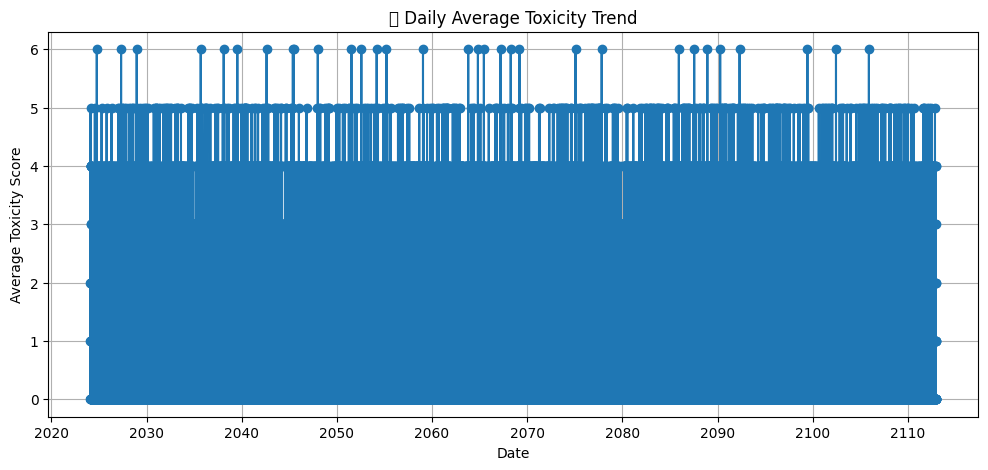

In [100]:
plt.figure(figsize=(12,5))
plt.plot(
    daily_toxicity['date'],
    daily_toxicity['toxicity_score'],
    marker='o'
)
plt.title("📉 Daily Average Toxicity Trend")
plt.xlabel("Date")
plt.ylabel("Average Toxicity Score")
plt.grid(True)
plt.show()


In [101]:
from statsmodels.tsa.arima.model import ARIMA

# Prepare time series
ts = daily_toxicity.set_index('date')['toxicity_score']

# Train ARIMA
model = ARIMA(ts, order=(2,1,2))
model_fit = model.fit()

model_fit.summary()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:         toxicity_score   No. Observations:                32450
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -55775.405
Date:                Tue, 23 Dec 2025   AIC                         111560.811
Time:                        00:48:25   BIC                         111602.748
Sample:                    02-08-2024   HQIC                        111574.217
                         - 12-12-2112                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9977      0.036    -27.568      0.000      -1.069      -0.927
ar.L2         -0.0054      0.006     -0.958      0.338      -0.016       0.006
ma.L1         -0.0074      0.036     -0.207      0.836      -0.077       0.063
ma.L2         -0.9925      0.036    -27.829      0.000      -1.062      -0.923
sigma2         1.8213      0.015    124.242      0.000       1.793       1.850
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              5778.16
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.02   Skew:                             1.03
Prob(H) (two-sided):                  0.25   Kurtosis:                         2.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [102]:
# Forecast next 7 days
forecast = model_fit.forecast(steps=7)

forecast_dates = pd.date_range(
    start=ts.index[-1] + pd.Timedelta(days=1),
    periods=7
)

forecast_df = pd.DataFrame({
    'date': forecast_dates,
    'predicted_toxicity': forecast
})

forecast_df


,date,predicted_toxicity
2112-12-13,2112-12-13,1.086912
2112-12-14,2112-12-14,1.080103
2112-12-15,2112-12-15,1.081045
2112-12-16,2112-12-16,1.080142
2112-12-17,2112-12-17,1.081038
2112-12-18,2112-12-18,1.080149
2112-12-19,2112-12-19,1.081031


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.



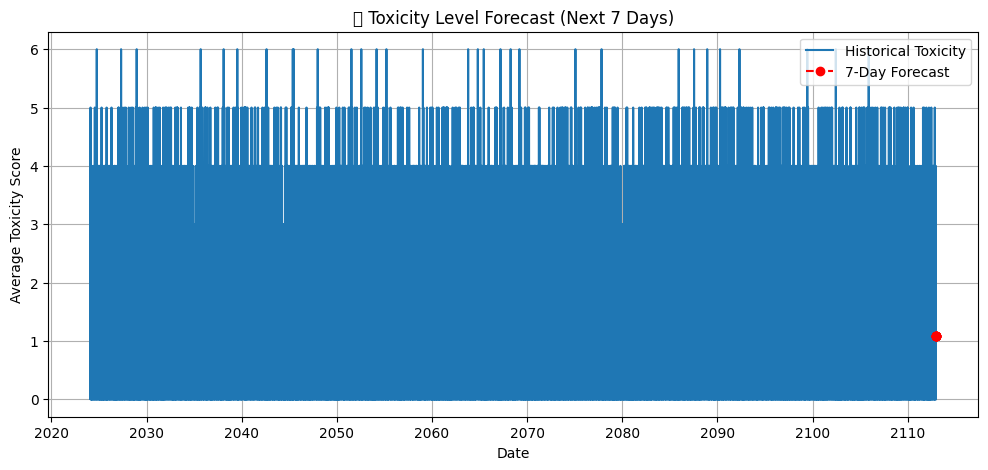

In [103]:
plt.figure(figsize=(12,5))

plt.plot(ts.index, ts.values, label='Historical Toxicity')
plt.plot(
    forecast_df['date'],
    forecast_df['predicted_toxicity'],
    marker='o',
    linestyle='--',
    color='red',
    label='7-Day Forecast'
)

plt.title("🔮 Toxicity Level Forecast (Next 7 Days)")
plt.xlabel("Date")
plt.ylabel("Average Toxicity Score")
plt.legend()
plt.grid(True)
plt.show()


In [104]:
import matplotlib.pyplot as plt

def forecast_next_7_days():
    # Forecast
    forecast = model_fit.forecast(steps=7)

    forecast_dates = pd.date_range(
        start=ts.index[-1] + pd.Timedelta(days=1),
        periods=7
    )

    forecast_df = pd.DataFrame({
        'Date': forecast_dates.astype(str),
        'Predicted Toxicity Level': forecast.round(3)
    })

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(ts.index, ts.values, label="Historical Toxicity")
    plt.plot(
        forecast_dates,
        forecast,
        marker='o',
        linestyle='--',
        color='red',
        label="7-Day Forecast"
    )
    plt.title("🔮 Toxicity Level Forecast (Next 7 Days)")
    plt.xlabel("Date")
    plt.ylabel("Avg Toxicity")
    plt.legend()
    plt.grid(True)

    return forecast_df, plt


In [105]:
forecast_iface = gr.Interface(
    fn=forecast_next_7_days,
    inputs=[],
    outputs=[
        gr.Dataframe(
            label="📅 7-Day Toxicity Forecast"
        ),
        gr.Plot(
            label="📈 Toxicity Trend Forecast"
        )
    ],
    title="🔮 Toxicity Forecasting Dashboard",
    description="""
    This module predicts how average toxicity levels are expected to change
    over the next 7 days using a time-series ARIMA model.
    """,
    theme="soft"
)

forecast_iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ed2730a3c66e2963ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [106]:
gr.TabbedInterface(
    [iface, forecast_iface],
    tab_names=[
        "🚨 Toxicity Classification",
        "🔮 Toxicity Forecasting"
    ]
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://926e985fb3b08a1b0a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
